In [16]:
import numpy as np 
import pandas as pd 
import pickle 
from neo import get_io
import os 
import matplotlib.pyplot as plt

In [17]:
with open('dict_data_CC_step.pkl', 'rb') as fichier:
    dict_data_CC = pickle.load(fichier)

In [18]:
working_directory = os.path.join(os.getcwd()).replace(" ", "_")
dataset_name = "Whole cell patch-clamp recordings of cerebellar granule cells"
dataset_version = "v1"
dataset_directory = os.path.join(os.getcwd())
list_folders = os.listdir(path=dataset_directory) # get list of folders

df_path_subject_id = pd.DataFrame(columns=('subject_id', 'path_data', 'files')) # create the dataframe
df_path_subject_id['subject_id'] = [folder for folder in list_folders if folder.startswith('GrC') and os.path.isdir(os.path.join(dataset_directory, folder))] # get the id of each Subject
df_path_subject_id['path_data'] = df_path_subject_id['subject_id'].apply(lambda x: os.path.join(dataset_directory, x)) # get the path of the folder of each subject
df_path_subject_id['files'] = df_path_subject_id['path_data'].apply(os.listdir) # get in a list the data files 
df_path_subject_id.head()

,subject_id,path_data,files
0,GrC_Subject01_010818,/home/abonard/Documents/EBRAINS/Curation/Examp...,[010818_0002 CC step.abf]
1,GrC_Subject02_050918,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[050918_0005 IV -70.abf, 050918_0006 CC step.abf]"
2,GrC_Subject03_060918,/home/abonard/Documents/EBRAINS/Curation/Examp...,[060918_0001 CC step.abf]
3,GrC_Subject04_070918,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[070918_0000 IV -70.abf, 070918_0001 CC step.abf]"
4,GrC_Subject05_080316,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[080316_0000 IV -70.abf, 080316_0001 CC step.abf]"


In [19]:

def plot_data(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times, signal)
    #plt.xlim(0.0, 1) # MODIFIED REGULARLY
    #plt.ylim(-72,-60)
    plt.xlabel(f"Time ({signal.times.units.dimensionality})")
    plt.ylabel(f"Membrane potential (signal.units.dimensionality)")
    
def plot_data_zoom(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times - signal.t_start, signal)
        plt.xlim(0.05, 0.5)
        plt.xlabel(f"Time ({signal.times.units.dimensionality})")
        plt.ylabel(f"Membrane potential ({signal.units.dimensionality})")



In [21]:
#Création d'une fonction qui permet d'avoir le début de la dépolarisation et la fin de l'hyperpolarisation
def onset(file_path):
    #Création de 3 liste vide
    var_signal0 = []
    var_signal1 = []
    var_signal = []
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        signalv = np.array(signal)

        #moyenne du repos
        mean = sum(signalv[:10])/len(signalv[:10])
        
        #intervalle des valeurs considérer au repos
        interp = mean + 3
        interm = mean - 3
        
        #récupération des indices ou le signal change
        var_signal= [i for i, x in enumerate(signalv) if x > interp or x < interm]
        
        #si il y a une valeur dans var_signal alors on rajoute la 1er valeur
        #dans var_signal0 = début de la variation du signal
        #la dernière valeur dans var_signal1 = fin de la variation du signal
        if len(var_signal) > 0:
            var_signal0.append(var_signal[0])
            var_signal1.append(var_signal[-1])
            #on récupère la plus petit valeur dans chaque signal
    var0 = min(var_signal0)
    var1 = min(var_signal1)
    return signal.times[var0]-signal.times[0], signal.times[var1]-signal.times[0]



In [8]:
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if '-70' in file:
            file_path = f"{folder_path}/{file}"
            print(file_path)


/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject02_050918/050918_0005 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject04_070918/070918_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject05_080316/080316_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject06_090216/090216_0002  IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject07_100918/100918_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject08_101018/101018-B_0006 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_

In [9]:
file_path

'/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject28_240216/240216-B_0000 IV -70.abf'

In [10]:
data = get_io(file_path).read(lazy=True)


In [11]:
data[0].segments[0].analogsignals[0].t_start

array(0.) * s

In [12]:
onset('/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject01_010818/010818_0002 CC step.abf')

(array(0.10033) * s, array(2.10677) * s)

### MEAN AU REPOS

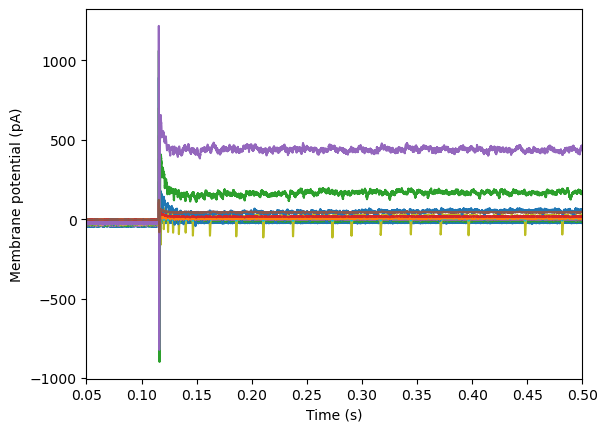

In [13]:
plot_data_zoom(file_path)

AxonIO: /home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject28_240216/240216-B_0000 IV -70.abf
nb_block: 1
nb_segment:  [8]
signal_streams: [Signals (chans: 2)]
signal_channels: [IN0, leak1]
spike_channels: []
event_channels: [Tag]

[[ -6.7138667  -0.9765625]
 [-14.038085   -1.6479492]
 [ -8.544922   -1.0986328]
 ...
 [-15.86914    -1.8920898]
 [ -9.765625   -1.2207031]
 [-14.038085   -1.7089844]] pA


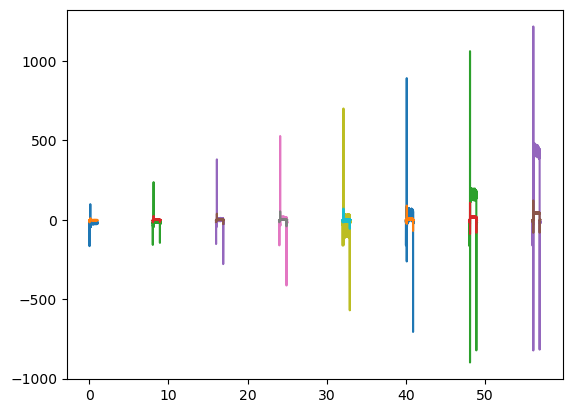

In [14]:
file_path_IV = '/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject28_240216/240216-B_0000 IV -70.abf'
reader_IV = get_io(file_path_IV)
print(reader_IV)
data_IV = reader_IV.read(lazy=True)
print(data_IV[0].segments[5].analogsignals[0])
print(data_IV[0].segments[5].analogsignals[0].load())
for segment in data_IV[0].segments:
    signal = segment.analogsignals[0].load()
    plt.plot(signal.times, signal)


## ONSET OFFSET FUNCTION

0.01565000000000083 s 0.9168499999999966 s


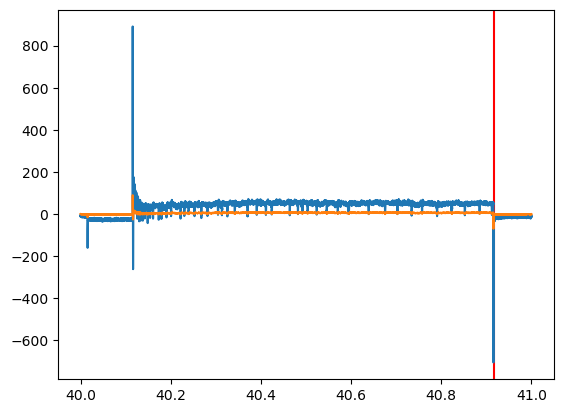

In [114]:
def onset(file_path): 
    var_signal0 = []
    var_signal1 = []
    var_signal = []

    data = get_io(file_path).read(lazy=True) # load data

    for segment in data[0].segments: # if several channels in one segment
        signal = data[0].segments[5].analogsignals[0].load()
        signal_array = np.array(signal)
        signal_array_chn0 = signal_array[:, 0]
        signal_array_chn1 = signal_array[:, 1]

    for segment in data[0].segments: # if not # todo: adapt with if and if not skip what is commented 
        #signal = data[0].segments[5].analogsignals[0].load()
        #signal_array = np.array(signal)

        mean = sum(signal_array_chn1[:10])/len(signal_array_chn1[:10]) # mean resting potential

        interp = mean + 3 # upper threshold 
        interm = mean - 3 # lower threshold 

        # todo: change the name of the variables 
        var_signal= [i for i, x in enumerate(signal_array_chn1) if x > interp or x < interm] # detect a larger variation beyond +3 and -3

    if len(var_signal) > 0: # index list of all the detected variations
        var_signal0.append(var_signal[0])
        var_signal1.append(var_signal[-1]) 

    # takes the first index corresponding to the first variation detected 
    var0 = min(var_signal0)
    var1 = min(var_signal1)

    return ('onset', signal.times[var0], 'offset',signal.times[var1]) # returns the onset: the time of the first variation and the offset: the time of the last variation


print(signal.times[var0]-signal.times[0], signal.times[var1]-signal.times[0])
plt.axvline(signal.times[var1], color ='r')
plt.plot(data[0].segments[5].analogsignals[0].load().times, data[0].segments[5].analogsignals[0].load())

In [104]:
signal.times[0]

array(40.) * s

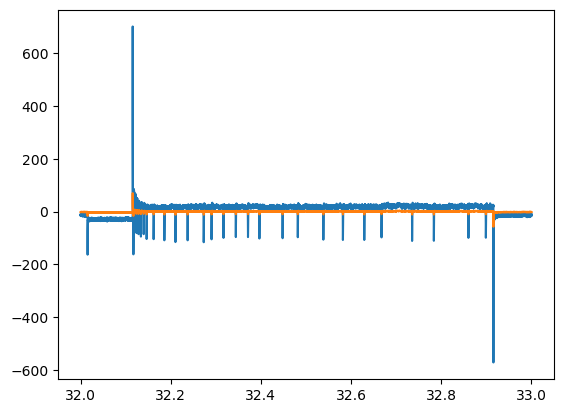

In [94]:
plt.plot(data[0].segments[4].analogsignals[0].load().times, data[0].segments[4].analogsignals[0].load())

In [90]:
signal = data[0].segments[2].analogsignals[0].load()
signal_array = np.array(signal)
signal_array_chn0 = signal_array[:, 0]
signal_array_chn1 = signal_array[:, 1]
mean = sum(signal_array_chn0[:10])/len(signal_array_chn0[:10])
interp = mean + 3
interm = mean - 3
var_signal= [i for i, x in enumerate(signal_array_chn0) if x > interp or x < interm]


print(var_signal)

[5, 6, 18, 19, 41, 43, 56, 61, 62, 70, 75, 85, 89, 98, 100, 103, 105, 107, 111, 114, 115, 119, 123, 124, 126, 127, 132, 134, 135, 142, 148, 151, 156, 157, 160, 168, 185, 188, 192, 196, 197, 198, 210, 216, 217, 230, 249, 255, 263, 265, 276, 277, 279, 287, 295, 306, 309, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 

In [89]:
signal = data[0].segments[4].analogsignals[0].load()
signal_array = np.array(signal)
signal_array_chn0 = signal_array[:, 0]
signal_array_chn1 = signal_array[:, 1]
mean = sum(signal_array_chn0[:10])/len(signal_array_chn0[:10])
interp = mean + 3
interm = mean - 3
var_signal= [i for i, x in enumerate(signal_array_chn0) if x > interp or x < interm]


print(var_signal)

[13, 17, 28, 30, 40, 41, 59, 60, 61, 73, 76, 87, 89, 97, 108, 111, 118, 120, 122, 125, 138, 141, 142, 143, 147, 148, 149, 167, 170, 176, 180, 183, 186, 195, 196, 197, 202, 211, 214, 215, 216, 222, 225, 241, 245, 251, 255, 257, 267, 268, 272, 274, 278, 279, 284, 285, 287, 288, 291, 293, 294, 297, 303, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451

### Seperate the two channels 

In [53]:
# Seperate the two channels 

for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signal_array = np.array(segment.analogsignals[0].load())
signal_array_chn0 = signal_array[:, 0]
signal_array_chn1 = signal_array[:, 1]


### Def onset

In [55]:
var_signal0 =[]
var_signal1=[]
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)

    #moyenne du repos
    mean = sum(signal_array_chn0[:10])/len(signal_array_chn0[:10])
    
    #intervalle des valeurs considérer au repos
    interp = mean + 3
    interm = mean - 3
    
    #récupération des indices ou le signal change
    var_signal= [i for i, x in enumerate(signal_array_chn0) if x > interp or x < interm]
    
    #si il y a une valeur dans var_signal alors on rajoute la 1er valeur
    #dans var_signal0 = début de la variation du signal
    #la dernière valeur dans var_signal1 = fin de la variation du signal
    if len(var_signal) > 0:
        var_signal0.append(var_signal[0])
        var_signal1.append(var_signal[-1])
        #on récupère la plus petit valeur dans chaque signal
var0 = min(var_signal0)
var1 = min(var_signal1)
print(signal.times[var0]-signal.times[0], signal.times[var1]-signal.times[0])
threshold_on = signal.times[var0]-signal.times[0]

0.0006500000000002615 s 0.9998999999999967 s


In [61]:
def detect_changes(data, threshold=1.0):
    """
    Détecte les points de changement dans des données continues.

    :param data: Liste ou tableau de données continues.
    :param threshold: Seuil pour détecter un changement significatif dans la variation.
                      Plus le seuil est bas, plus la fonction détectera de changements.
    :return: Liste des indices où des changements sont détectés.
    """
    # Calculer la première différence (variation entre chaque point consécutif)
    diff = np.diff(data)
    print(diff)
    
    # Trouver les indices où la différence est supérieure au seuil
    change_points = np.where(np.abs(diff) > threshold)[0]
    
    # Retourner les indices de changements détectés
    return change_points

# Exemple d'utilisation
data = signal_array_chn1
change_points = detect_changes(signal_array_chn1, threshold=2.0)
print("Changements détectés aux indices:", change_points)
print(signal.times[change_points])

[ 0.18310547 -0.06103516 -0.36621094 ...  0.         -0.18310547
  0.48828125]
Changements détectés aux indices: [  312   313   314   315  2312  2313  2314  2315  2316  2317  2318  2319
  2320  2321  2322  2323  2324  2325  2326  2327  2328  2329  2330  2331
  2332  2333  2334  2335  2337  2363 10730 17012 18312 18313 18314 18315
 18316 18317 18318 18319 18320 18321]
[56.0156  56.01565 56.0157  56.01575 56.1156  56.11565 56.1157  56.11575
 56.1158  56.11585 56.1159  56.11595 56.116   56.11605 56.1161  56.11615
 56.1162  56.11625 56.1163  56.11635 56.1164  56.11645 56.1165  56.11655
 56.1166  56.11665 56.1167  56.11675 56.11685 56.11815 56.5365  56.8506
 56.9156  56.91565 56.9157  56.91575 56.9158  56.91585 56.9159  56.91595
 56.916   56.91605] s


In [62]:
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signal_array = np.array(signal)
signal_array_chn0 = signal_array[:, 0]
signal_array_chn1 = signal_array[:, 1]

for segment in data[0].segments:
    for i in df_signal[segment]: 
        if i > interp or i < interm:
            index_up = df_signal.index.get_loc(df_signal[df_signal[0] >= interp].index[0])
            index_down = df_signal.index.get_loc(df_signal[df_signal[0] >= interm].index[0])
            
            threshold_up = df_signal['time'].iloc[index_up]
            threshold_down = df_signal['time'].iloc[index_down]
    plt.plot(df_signal['time'], df_signal[segment])
    plt.axvline(threshold_on, color='r')
    plt.show()

AnalogSignal with 2 channels of length 20000; units pA; datatype float32
name: 'Signals'
annotations: {'stream_id': '0'}
sampling rate: 20000.0 Hz
time: 56.0 s to 57.0 s

In [60]:
import numpy as np

def detect_changes(data, threshold=1.0):
    """
    Détecte les points de changement dans des données continues.

    :param data: Liste ou tableau de données continues.
    :param threshold: Seuil pour détecter un changement significatif dans la variation.
    :return: Liste des indices où des changements sont détectés.
    """
    # Calculer la première différence (variation entre chaque point consécutif)
    diff = np.diff(data)
    
    # Trouver les indices où la différence est supérieure au seuil
    change_points = np.where(np.abs(diff) > threshold)[0]
    
    # Retourner les indices de changements détectés
    return change_points

# Exemple d'utilisation
data = [1, 2, 3, 8, 9, 15, 16, 17, 10, 5, 4]
change_points = detect_changes(data, threshold=2.0)

# Supposons que vous avez un autre tableau `correspondances`
correspondances = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'])

# Trouver les valeurs correspondantes dans `correspondances` en utilisant les indices trouvés
valeurs_correspondantes = correspondances[change_points]

print("Indices de changements détectés:", change_points)
print("Valeurs correspondantes dans l'autre tableau:", valeurs_correspondantes)


Indices de changements détectés: [2 4 7 8]
Valeurs correspondantes dans l'autre tableau: ['c' 'e' 'h' 'i']


In [42]:
# Pandas dataframe version
# rebuild signal -70 IV in dataFrame Pandas 
df_signal = pd.DataFrame()
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signal_array = np.array(segment.analogsignals[0].load())

    # Array to Dataframe pandas
    df = pd.DataFrame(signal_array)
    df_signal = pd.concat([df_signal,df], axis=1)
# Columns name 
df_signal.columns = [ j for j in range (len(df_signal.columns))] # columns 0,1 -> columns [0:1:16]
# Add time to df_signal 
df_time = pd.DataFrame(data[0].segments[0].analogsignals[0].load().times, columns=['time'])
df_signal = pd.concat([df_time , df_signal], axis = 1)

#for columns in df_signal.columns:
mean = sum(df_signal[2][:10])/len(df_signal[:10])
interp = mean + 3
interm = mean - 3

# Peak detection 
list_peak = []
list_peak = spike_train_generation.peak_detection(signal_array)

# Event detection 

for i in df_signal[2]: 
    if i > interp or i < interm:
         index_up = df_signal.index.get_loc(df_signal[df_signal[0] >= interp].index[0])
         index_down = df_signal.index.get_loc(df_signal[df_signal[0] >= interm].index[0])
         threshold_up = df_signal['time'].iloc[index_up]
         threshold_down = df_signal['time'].iloc[index_down]


print(threshold_up)
print(threshold_down)



AttributeError: 'numpy.ndarray' object has no attribute 'times'

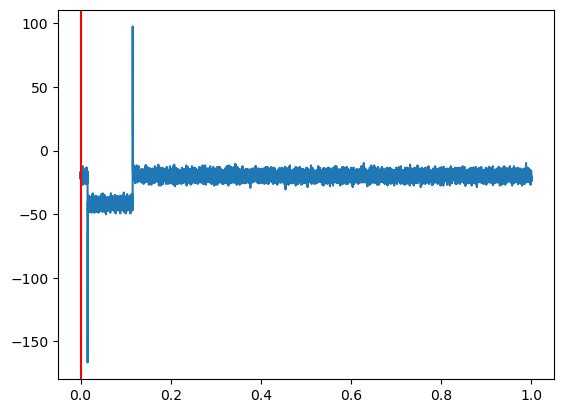

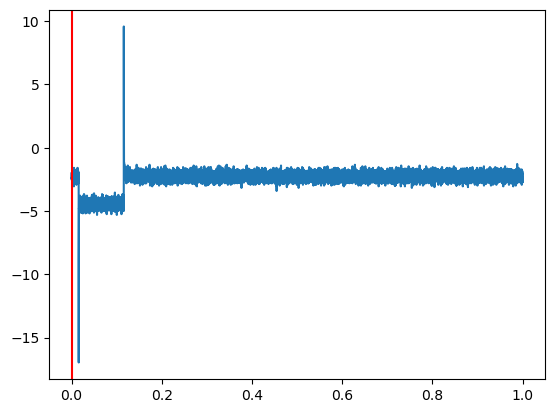

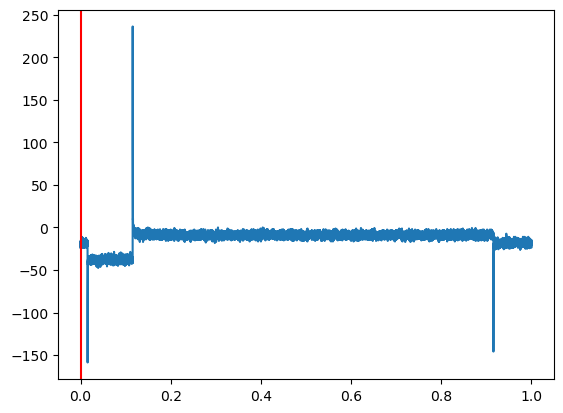

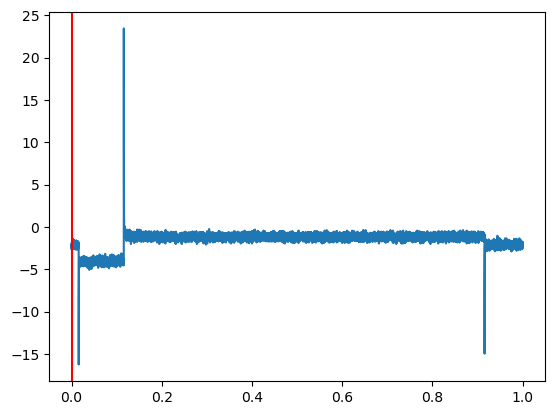

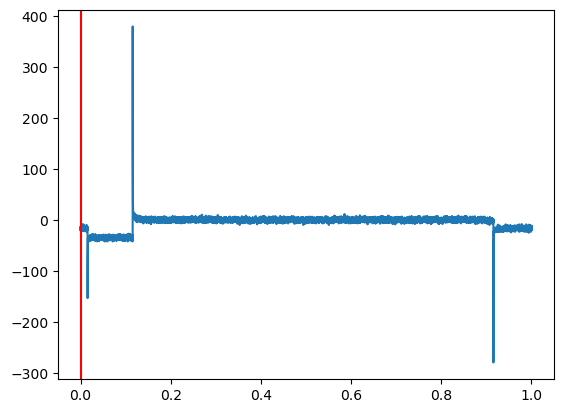

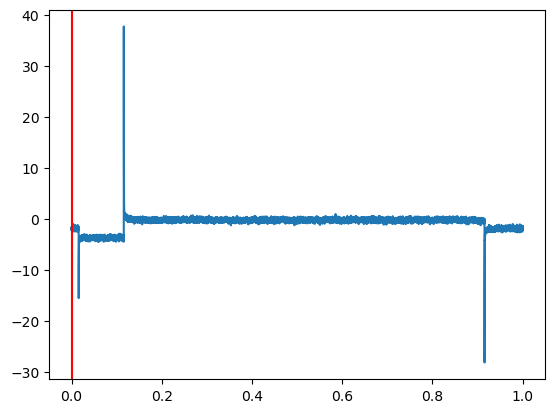

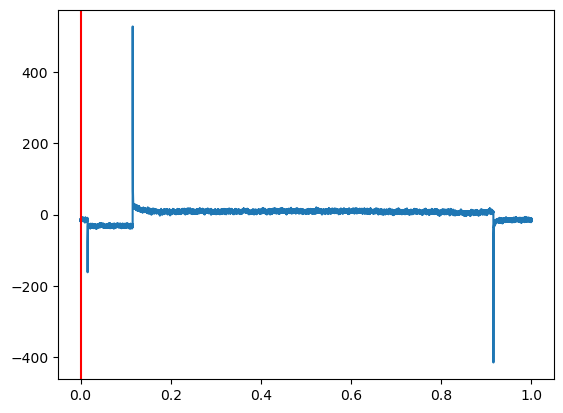

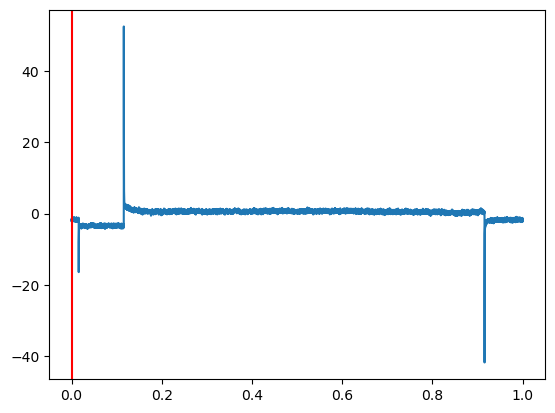

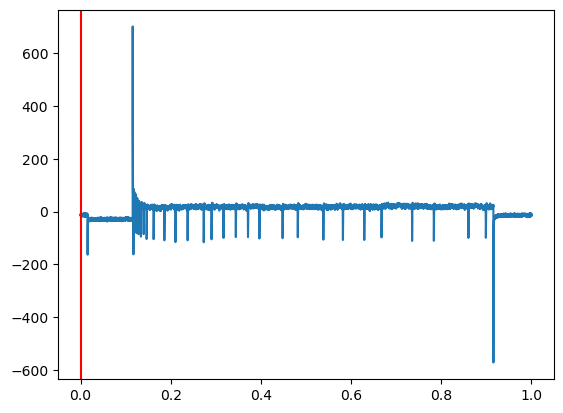

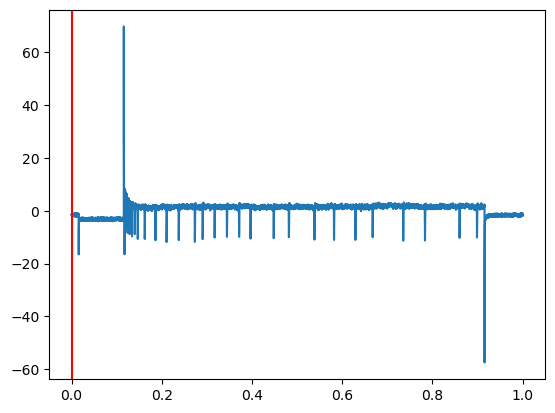

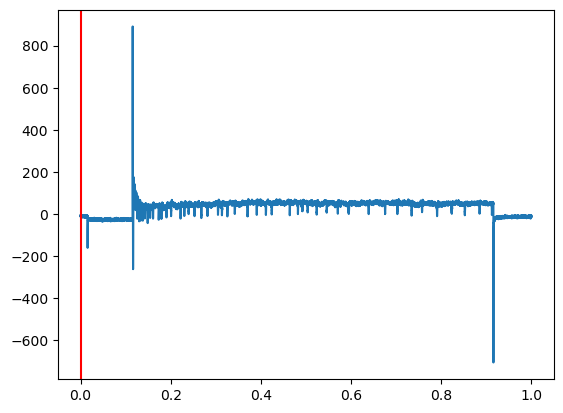

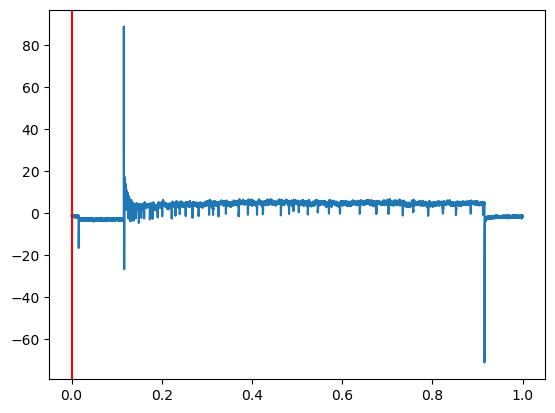

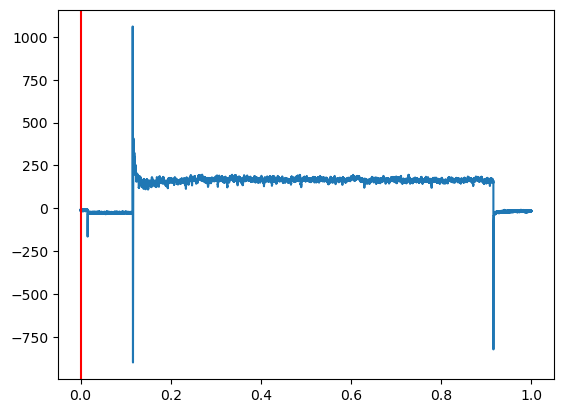

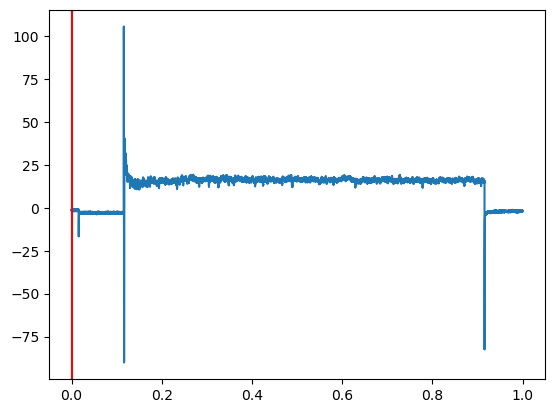

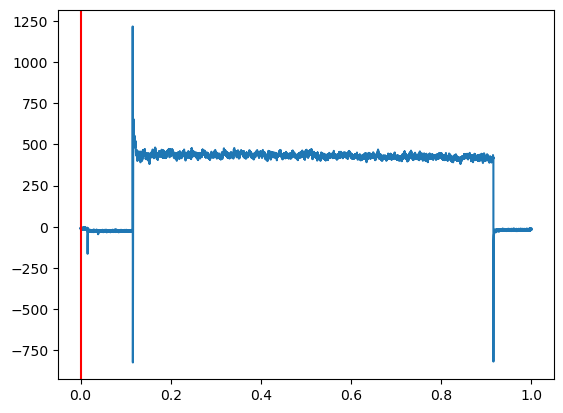

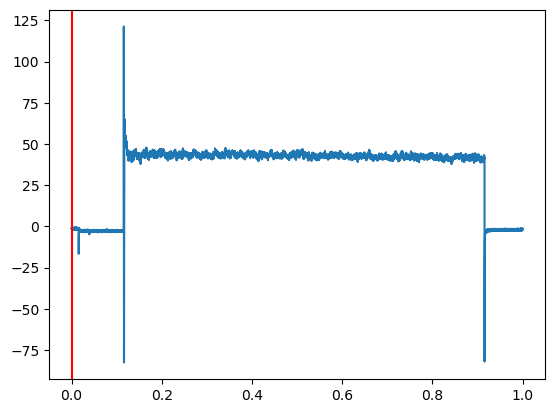

In [56]:
for segment in df_signal.columns[1:]:
    for i in df_signal[segment]: 
        if i > interp or i < interm:
            index_up = df_signal.index.get_loc(df_signal[df_signal[0] >= interp].index[0])
            index_down = df_signal.index.get_loc(df_signal[df_signal[0] >= interm].index[0])
            
            threshold_up = df_signal['time'].iloc[index_up]
            threshold_down = df_signal['time'].iloc[index_down]
    plt.plot(df_signal['time'], df_signal[segment])
    plt.axvline(threshold_on, color='r')
    plt.show()

In [52]:
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signal_array = np.array(segment.analogsignals[0].load())
signal_array_chn0 = signal_array[:, 0]
signal_array_chn1 = signal_array[:, 1]


In [45]:
for i in range(signal_array.shape[0]):  # Parcours des lignes
    for j in range(signal_array.shape[1]):  # Parcours des colonnes
        value = signal_array[i, j]
    print(value)

-1.159668
-0.9765625
-1.0375977
-1.4038086
-1.2817383
-1.2817383
-1.2207031
-1.3427734
-1.0986328
-1.0986328
-1.0375977
-1.2817383
-1.2207031
-1.6479492
-1.7089844
-1.3427734
-1.0986328
-0.61035156
-1.4038086
-1.3427734
-1.2207031
-1.2817383
-1.0986328
-1.2817383
-1.5258789
-1.0986328
-1.7089844
-1.3427734
-1.2207031
-1.5869141
-0.91552734
-1.2817383
-2.1362305
-0.8544922
-0.9765625
-1.0986328
-1.5258789
-1.3427734
-1.4648438
-1.5869141
-1.2817383
-0.8544922
-1.0375977
-1.6479492
-1.4038086
-1.2207031
-1.2817383
-1.4648438
-1.0986328
-1.3427734
-1.4038086
-1.2207031
-1.2817383
-1.2207031
-1.159668
-1.6479492
-1.3427734
-1.0986328
-1.2207031
-1.159668
-1.2207031
-1.953125
-0.79345703
-0.7324219
-1.5869141
-1.2207031
-0.9765625
-1.3427734
-1.5869141
-1.2817383
-1.4038086
-1.2817383
-0.9765625
-1.7089844
-1.159668
-1.2817383
-1.2207031
-1.0986328
-1.7089844
-0.9765625
-1.4648438
-1.6479492
-1.4038086
-1.2817383
-1.2207031
-1.3427734
-1.3427734
-1.2207031
-1.3427734
-1.6479492
-0.91552734


In [134]:
var_signal = []
var_signal0 = []
var_signal1 = []
var_signal = []

for i, x in enumerate(df_signal[0]):
     if x > interp or x < interm:
        var_signal.append(i)
if len(var_signal) > 0:
    var_signal0.append(var_signal[0])
    var_signal1.append(var_signal[-1])

var0 = min(var_signal0)
var1 = min(var_signal1)



19999

In [49]:
signal = data_IV[0].segments[0].analogsignals[0].load()
signalv = np.array(signal)

#moyenne du repos
mean = sum(signalv[:10])/len(signalv[:10])
print(mean)

[-19.714354   -2.2521973]


In [27]:
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)

    #moyenne du repos
    mean = sum(signalv[:10])/len(signalv[:10])
print(mean)

[-9.033203  -1.1901855]


In [48]:
data[0].segments[5].analogsignals[0].load() 

AnalogSignal with 2 channels of length 20000; units pA; datatype float32
name: 'Signals'
annotations: {'stream_id': '0'}
sampling rate: 20000.0 Hz
time: 40.0 s to 41.0 s

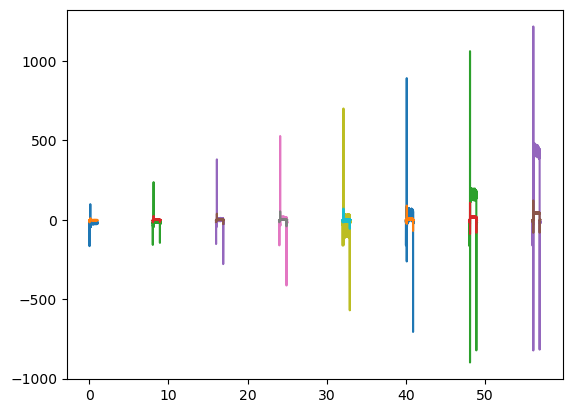

In [39]:
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    plt.plot(signal.times, signal)


               0          0          0          0          0          0  \
0     -20.751951 -20.141600 -15.869140 -18.310547 -14.038085  -6.713867   
1     -21.972654 -18.920898 -15.258788 -12.207030 -10.986327 -14.038085   
2     -20.751951 -19.531250 -16.479492 -14.648437 -10.986327  -8.544922   
3     -17.700195 -24.414061 -17.089844 -13.427733 -14.038085  -8.544922   
4     -19.531250 -18.920898 -17.089844 -12.207030 -12.207030 -14.038085   
...          ...        ...        ...        ...        ...        ...   
19995 -18.310547 -23.803709 -11.596679 -14.648437 -12.817382  -7.324218   
19996 -22.583006 -15.869140 -15.869140 -15.258788 -17.700195 -13.427733   
19997 -22.583006 -20.141600 -20.141600 -14.648437  -7.934570 -15.869140   
19998 -20.141600 -18.920898 -15.869140 -12.817382 -15.258788  -9.765625   
19999 -23.193357 -15.258788 -11.596679 -17.700195 -10.986327 -14.038085   

               0          0  
0     -11.596679  -8.544922  
1      -8.544922  -7.324218  
2     -15

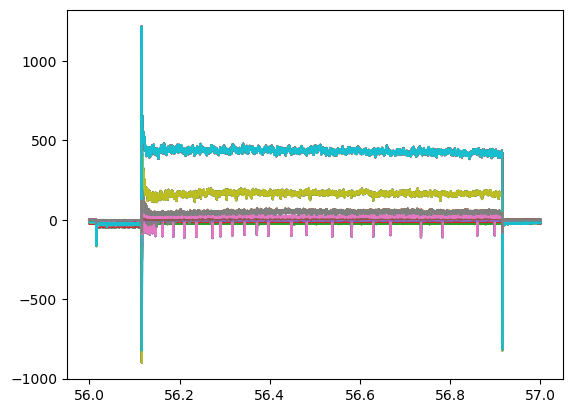

In [77]:
for column in df_signal.columns[0:]:
    plt.plot(segment.analogsignals[0].load().times, df_signal[column])   
    print(df_signal[column])